<a href="https://colab.research.google.com/github/J05ia5/ML-lab/blob/main/LAB_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Montamos nuestro drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# librerias
import numpy as np

In [4]:
# leemos el dataset
from scipy.io import arff
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Ciencias de la Computacion USFX/Quinto Semestre/AI/MyDatasets/kc_house_data.csv")

print(df)

               id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  grade  \
0             1180      5650     1.0           0     0  ...      7   
1             2570      7242   

### 1. Preparamos y limpiamos los datos

eliminamos columans que no aportan como `id` y `date`. Luego, separamos el objetivo (target) `price` de los features.

In [5]:
import matplotlib.pyplot as plt

# eliminamos columnas irrelevantes
df_cleaned = df.drop(['id', 'date'], axis=1)

# definimos el target y features
y = df_cleaned['price'].values
X = df_cleaned.drop('price', axis=1).values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (21613, 18)
Target shape: (21613,)


### 2. Normalizamos los features
como los features tienen diferentes escalas (ejm, bedrooms vs sqft_living), aplicamos Z-score normalization: $X = \frac{X - \mu}{\sigma}$.

In [6]:
def feature_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = feature_normalize(X)

# añadimos la columna de interceccion (columna de unos) a X
m = len(y)
X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("First 5 rows of normalized features (with intercept):\n", X_norm[:5, :])

First 5 rows of normalized features (with intercept):
 [[ 1.         -0.39873715 -1.44746357 -0.97983502 -0.22832133 -0.915427
  -0.08717263 -0.30575946 -0.62918687 -0.55883575 -0.73470764 -0.65868104
  -0.54489777 -0.21012839  1.87015159 -0.35257175 -0.30607896 -0.9433552
  -0.26071541]
 [ 1.         -0.39873715  0.1756067   0.53363434 -0.18988538  0.93650577
  -0.08717263 -0.30575946 -0.62918687 -0.55883575  0.46084084  0.2451414
  -0.6810785   4.7466776   0.87956753  1.16156823 -0.74634143 -0.43268619
  -0.18786773]
 [ 1.         -1.47395936 -1.44746357 -1.42625404 -0.12329847 -0.915427
  -0.08717263 -0.30575946 -0.62918687 -1.40958711 -1.22983377 -0.65868104
  -1.29389179 -0.21012839 -0.9333882   1.28353661 -0.13565477  1.07013975
  -0.17237524]
 [ 1.          0.67648506  1.14944885 -0.13055006 -0.2440144  -0.915427
  -0.08717263 -0.30575946  2.44429394 -0.55883575 -0.89169885  1.39751501
  -0.20444594 -0.21012839  1.08516045 -0.28328794 -1.271816   -0.91417411
  -0.28452184]
 [ 1.

### 3. Implementacion del descenso por el Gradiente
definimos la funcion de costo $J(\theta)$ y el algoritmo del descenso por el gradiente para minimizarlo

In [7]:
def compute_cost(X, y, theta):
    m = len(y)
    h = X.dot(theta)
    error = h - y
    J = (1 / (2 * m)) * np.sum(error**2)
    return J

def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = []

    for i in range(num_iters):
        h = X.dot(theta)
        gradient = (1 / m) * (X.T.dot(h - y))
        theta = theta - alpha * gradient
        J_history.append(compute_cost(X, y, theta))

    return theta, J_history

# iniciamos los parametros
alpha = 0.01
iterations = 1500
theta = np.zeros(X_norm.shape[1])

# corremos el entrenamiento
theta, cost_history = gradient_descent(X_norm, y, theta, alpha, iterations)

print("Optimized Theta:", theta)

Optimized Theta: [540087.98856731 -33143.91165563  31411.23967061  81643.4712548
   5536.25721022   3874.4704535   50461.3552184   40419.48885349
  17445.27871965 111332.15369853  76088.00188696  27061.88544809
 -76135.93256372   8238.62357258 -31014.97919814  83644.67046484
 -30679.37163462  16501.71453238 -10552.98837296]


### 4. Convergencia de la funcion de costo
usamos el historial de costo para asegurarnos de que el modelo esta aprendiendo(el costo decrese en el tiempo).

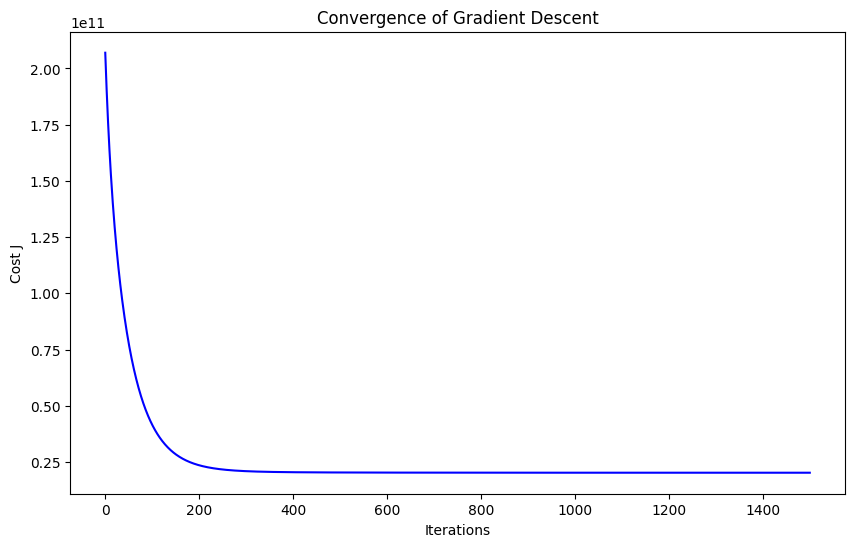

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(cost_history)), cost_history, 'b')
plt.xlabel('Iterations')
plt.ylabel('Cost J')
plt.title('Convergence of Gradient Descent')
plt.show()

### 5. Evaluamos con 100 predicciones
Comparamos el valor predicho contra el verdadero de los primeros 100 ejemplos

,Actual Price,Predicted Price,Difference
0,221900.0,2.081876e+05,13712.376309
1,538000.0,7.352926e+05,-197292.567897
2,180000.0,3.834640e+05,-203463.979475
3,604000.0,4.552737e+05,148726.331533
4,510000.0,4.396672e+05,70332.768483
5,1225000.0,1.457446e+06,-232446.343224
6,257500.0,2.757608e+05,-18260.776306
7,291850.0,1.322363e+05,159613.666450
8,229500.0,3.277847e+05,-98284.690970
9,323000.0,2.508541e+05,72145.935199


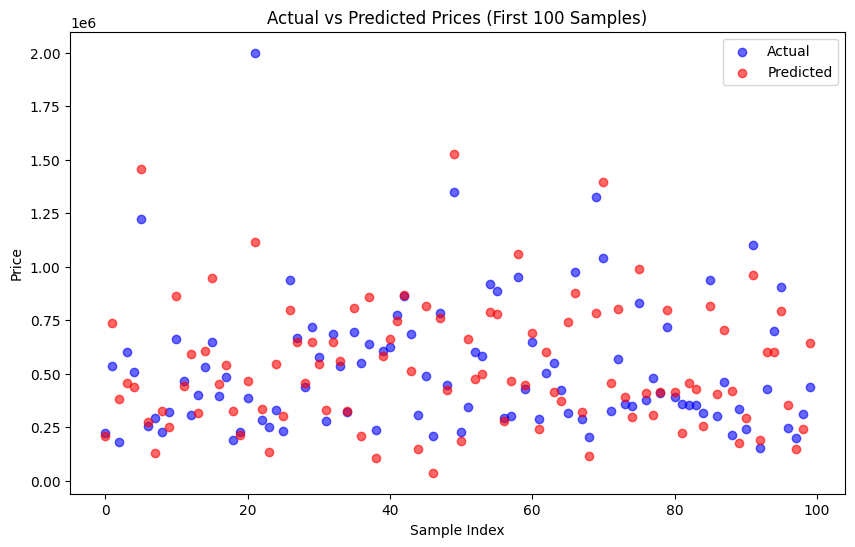

In [9]:
predictions = X_norm[:100].dot(theta)
actuals = y[:100]

comparison_df = pd.DataFrame({
    'Actual Price': actuals,
    'Predicted Price': predictions,
    'Difference': actuals - predictions
})

display(comparison_df.head(10))

# Scatter plot for visualization
plt.figure(figsize=(10, 6))
plt.scatter(range(100), actuals, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(100), predictions, color='red', label='Predicted', alpha=0.6)
plt.legend()
plt.title('Actual vs Predicted Prices (First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.show()

### 6. Implementacion de la Ecuacion de la Normal
La Ecuación Normal es una forma analítica de encontrar los coeficientes θ que minimizan la función de costo:
$$\theta = (X^T X)^{-1} X^T y$$

Una ventaja de este método es que no es necesario elegir una tasa de aprendizaje
𝛼
α ni realizar iteraciones. Además, la normalización o escalado de características no es estrictamente necesario para que este método funcione, aunque utilizaremos las mismas variables X definidas previamente.

In [10]:
# Prepara la matriz X incluyendo el término de intercepto para aplicar la Ecuación Normal (utilizando X sin normalizar con fines de demostración).
m_samples = len(y)
X_poly = np.concatenate([np.ones((m_samples, 1)), X], axis=1)

def normal_equation(X, y):
    # theta = inv(X.T * X) * X.T * y
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# Calcula los valores óptimos de **θ** utilizando la **Ecuación Normal**.
theta_normal = normal_equation(X_poly, y)

print("Theta obtained via Normal Equation:", theta_normal)

Theta obtained via Normal Equation: [-6.30985313e+06  3.05469424e+06  5.38803755e+05  4.08746130e+04
  8.31294154e-02  7.58679593e+05 -3.50237579e+06  3.75358221e+05
  3.92312640e+04 -3.64827985e+04 -4.07120234e+04 -4.08216619e+04
 -2.62022321e+03  1.98125837e+01 -5.82419867e+02  6.02748227e+05
 -2.14729829e+05  2.16814005e+01 -3.82641849e-01]


### 7. Evaluamos la ecuancion de la normal con 100 predicciones
Aplicamos la misma lógica de evaluación para observar cómo se comporta la solución analítica en comparación con la solución iterativa.


,Actual Price,Predicted (Normal Eq),Difference
0,221900.0,-3.180594e+06,3.402494e+06
1,538000.0,-1.338740e+06,1.876740e+06
2,180000.0,-5.959611e+06,6.139611e+06
3,604000.0,1.091096e+06,-4.870964e+05
4,510000.0,-2.592660e+06,3.102660e+06
5,1225000.0,2.166427e+06,-9.414270e+05
6,257500.0,-1.751613e+06,2.009113e+06
7,291850.0,-3.006653e+06,3.298503e+06
8,229500.0,-3.130950e+06,3.360450e+06
9,323000.0,-1.654997e+06,1.977997e+06


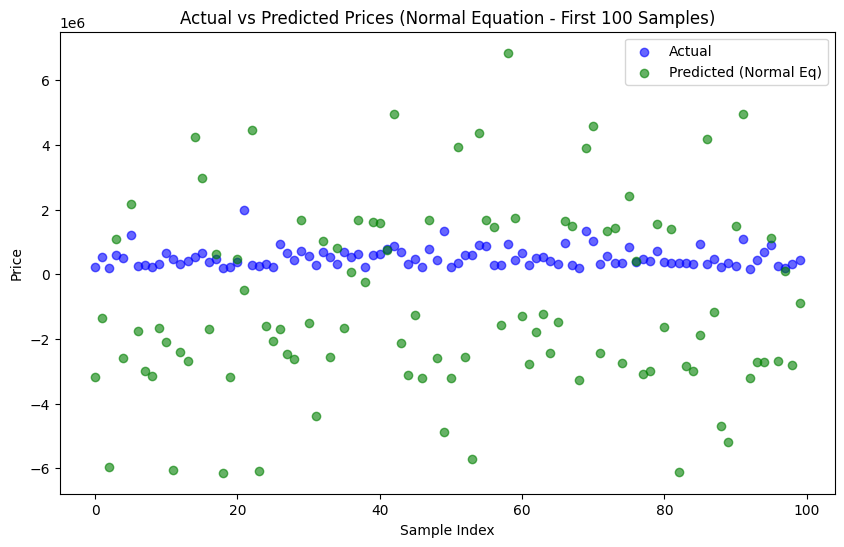

In [11]:
predictions_normal = X_poly[:100].dot(theta_normal)
actuals_normal = y[:100]

comparison_normal_df = pd.DataFrame({
    'Actual Price': actuals_normal,
    'Predicted (Normal Eq)': predictions_normal,
    'Difference': actuals_normal - predictions_normal
})

display(comparison_normal_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(range(100), actuals_normal, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(100), predictions_normal, color='green', label='Predicted (Normal Eq)', alpha=0.6)
plt.legend()
plt.title('Actual vs Predicted Prices (Normal Equation - First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.show()